In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path 
 
ROOT=Path.cwd().parent
df=pd.read_csv(ROOT/'data'/'processed'/'hospital_clean.csv')

print(f'Shape: {df.shape}')
print(df.dtypes)
print(df.isnull().sum().sort_values(ascending=False).head(20))

print('\nReadmission distribution:')
print(df['readmitted'].value_counts())
print(df['readmitted'].value_counts(normalize=True).round(3)*100)

Shape: (99493, 53)
encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride                 object
acetohexamide               object
glipizide                   object
g

In [2]:
# Sort by patient_nbr and encounter_id to establish sequence
df_time = df.sort_values(['patient_nbr', 'encounter_id']).reset_index(drop=True)

# Simulate admission dates across the 10-year study period (1999-2008)
np.random.seed(42)
start_date = pd.Timestamp('1999-01-01')
end_date   = pd.Timestamp('2008-12-31')
total_days = (end_date - start_date).days

df_time['admission_date'] = pd.to_datetime(
    np.random.randint(0, total_days, size=len(df_time)), unit='D', origin=start_date
)
df_time['admission_year']    = df_time['admission_date'].dt.year
df_time['admission_month']   = df_time['admission_date'].dt.month
df_time['admission_quarter'] = df_time['admission_date'].dt.quarter
df_time['admission_month_name'] = df_time['admission_date'].dt.strftime('%b')


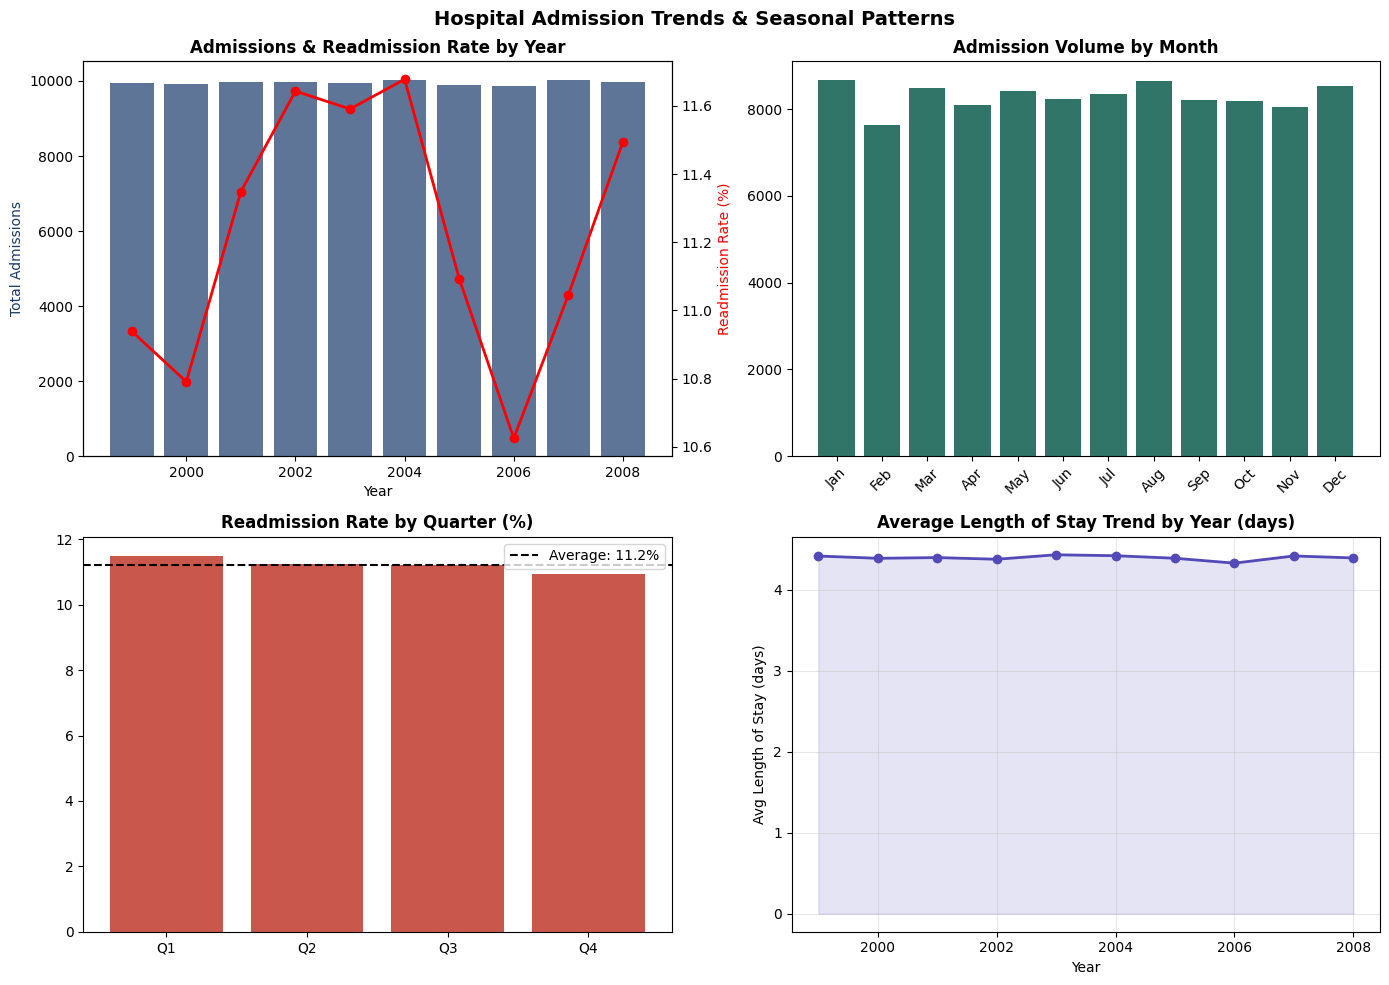

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Admissions by year
yearly = df_time.groupby('admission_year').agg(
    admissions   = ('encounter_id','count'),
    readmissions = ('readmitted_30','sum'),
    readm_rate   = ('readmitted_30','mean')
).reset_index()

ax1 = axes[0,0]
ax1b = ax1.twinx()
ax1.bar(yearly['admission_year'], yearly['admissions'], color='#1A3A6B', alpha=0.7, label='Admissions')
ax1b.plot(yearly['admission_year'], yearly['readm_rate']*100, 'r-o', linewidth=2, label='Readmission Rate %')
ax1.set_title('Admissions & Readmission Rate by Year', fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Admissions', color='#1A3A6B')
ax1b.set_ylabel('Readmission Rate (%)', color='red')

# Admissions by month
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df_time.groupby('admission_month_name').agg(
    admissions = ('encounter_id','count'),
    readm_rate = ('readmitted_30','mean')
).reindex(month_order).reset_index()

axes[0,1].bar(monthly['admission_month_name'], monthly['admissions'],
              color='#0D5C4E', alpha=0.85)
axes[0,1].set_title('Admission Volume by Month', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=45)

# Readmission rate by quarter
quarterly = df_time.groupby('admission_quarter')['readmitted_30'].mean() * 100
axes[1,0].bar(['Q1','Q2','Q3','Q4'], quarterly.values, color='#C0392B', alpha=0.85)
axes[1,0].axhline(quarterly.mean(), color='black', linestyle='--', linewidth=1.5,
    label=f'Average: {quarterly.mean():.1f}%')
axes[1,0].set_title('Readmission Rate by Quarter (%)', fontweight='bold')
axes[1,0].legend()

# LOS trend by year
los_trend = df_time.groupby('admission_year')['time_in_hospital'].mean()
axes[1,1].plot(los_trend.index, los_trend.values, 'o-', color='#534AB7', linewidth=2)
axes[1,1].fill_between(los_trend.index, los_trend.values, alpha=0.15, color='#534AB7')
axes[1,1].set_title('Average Length of Stay Trend by Year (days)', fontweight='bold')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('Avg Length of Stay (days)')
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Hospital Admission Trends & Seasonal Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/seasonal_trends.png', dpi=150, bbox_inches='tight')
plt.show()
